In [29]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

import math

from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from scipy.stats import f_oneway ,pearsonr, spearmanr

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV,RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import uniform, randint

In [30]:
df = pd.read_csv("../datos\StudentPerformanceFactors.csv")
df.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\USER\AppData\Local\Temp\ipykernel_18128\2030506606.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("../datos\StudentPerformanceFactors.csv")


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [32]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Veo que hay una nota q no corresponde al rengo de notas de 0-100 asi que luego en la parte de data cleaning voy a porceder a dropearla

In [33]:
### Chequeo si hay duplicdos

assert df.duplicated().sum() == 0

In [34]:
df.isna().mean()

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               0.011806
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      0.013622
Distance_from_Home            0.010141
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [35]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())
    print(f"Únicos: {df[col].nunique()}")

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Únicos: 3
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Únicos: 3
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Únicos: 2
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Únicos: 3
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Únicos: 2
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Únicos: 3
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64
Únicos: 3
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Únicos: 2
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
Únicos: 3
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
Únicos: 2
Parental_Education_Level
High School     3223
College         1989
Postgraduate 

### EDA

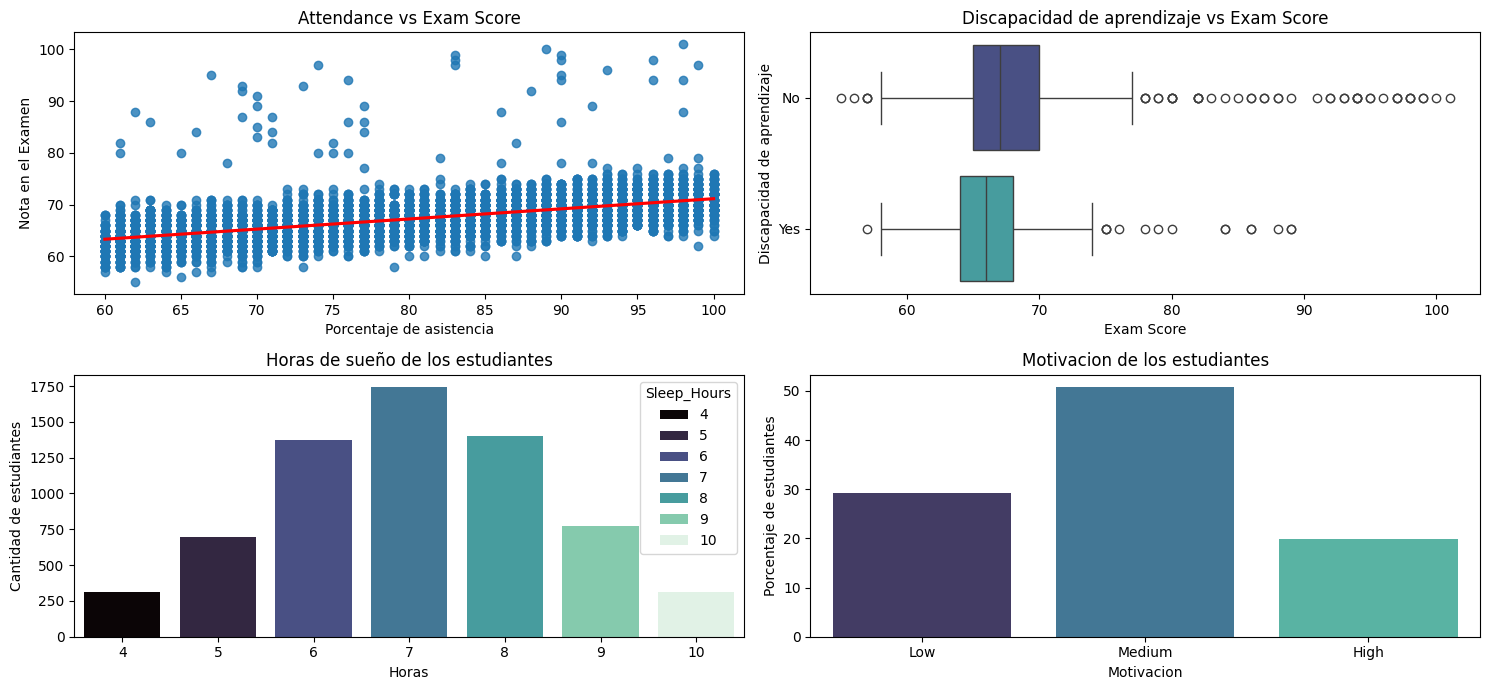

In [36]:
fig, ax = plt.subplots(2,2, figsize = (15,7))

sns.regplot(data=df, x="Attendance", y="Exam_Score",ax = ax[0][0],line_kws = {"color" : "red"})
ax[0][0].set_title("Attendance vs Exam Score")
ax[0][0].set_xlabel("Porcentaje de asistencia")
ax[0][0].set_ylabel("Nota en el Examen")


sns.boxplot(data=df, y="Learning_Disabilities",x = "Exam_Score",hue = "Learning_Disabilities",ax = ax[0][1],palette="mako")
ax[0][1].set_title("Discapacidad de aprendizaje vs Exam Score")
ax[0][1].set_xlabel("Exam Score")
ax[0][1].set_ylabel("Discapacidad de aprendizaje")


sns.countplot(data=df, x="Sleep_Hours",ax = ax[1][0],hue = "Sleep_Hours",palette="mako")
ax[1][0].set_title("Horas de sueño de los estudiantes")
ax[1][0].set_xlabel("Horas")
ax[1][0].set_ylabel("Cantidad de estudiantes")


sns.countplot(data=df, x="Motivation_Level",hue = "Motivation_Level" ,ax = ax[1][1],stat="percent",palette="mako")
ax[1][1].set_title("Motivacion de los estudiantes")
ax[1][1].set_xlabel("Motivacion")
ax[1][1].set_ylabel("Porcentaje de estudiantes")


plt.tight_layout()
plt.show()

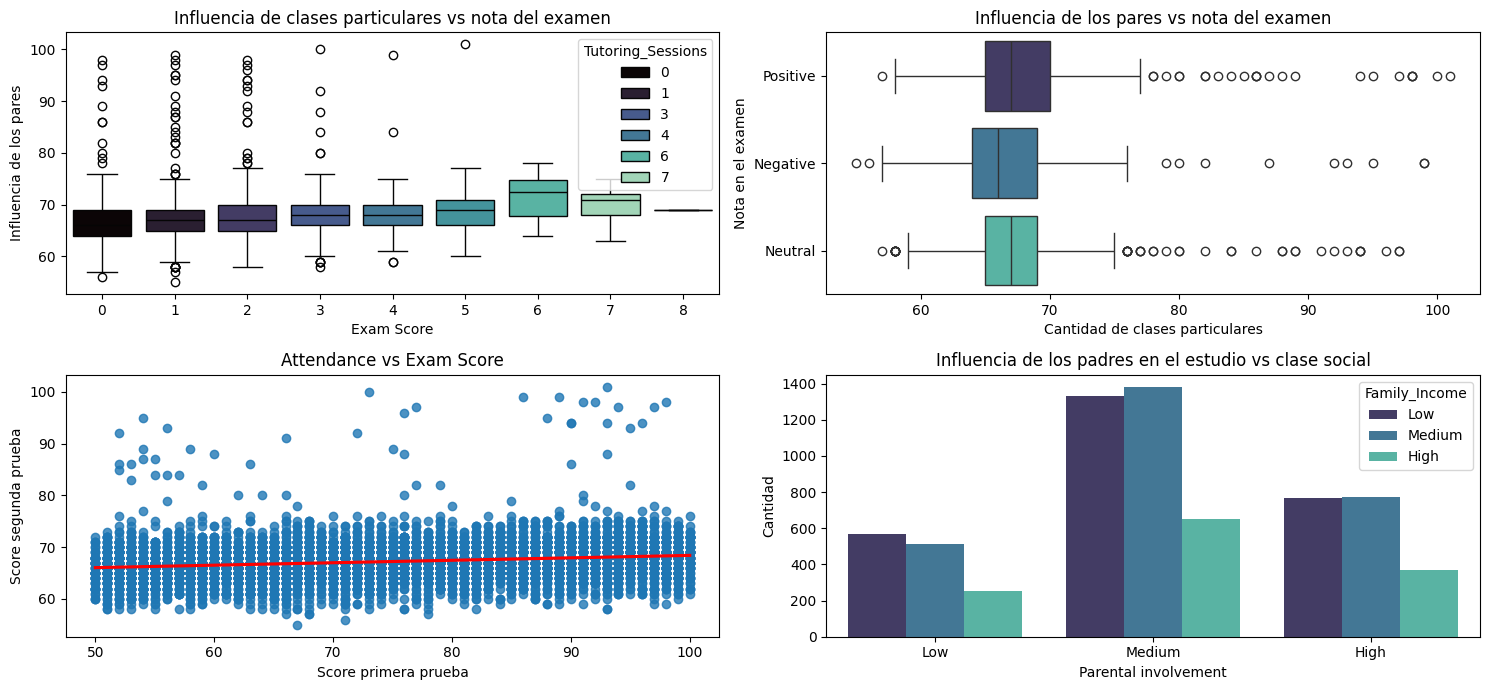

In [37]:
fig, ax = plt.subplots(2,2, figsize = (15,7))

sns.regplot(data=df, x="Previous_Scores", y="Exam_Score",ax = ax[1][0],line_kws = {"color" : "red"})
ax[1][0].set_title("Attendance vs Exam Score")
ax[1][0].set_xlabel("Score primera prueba")
ax[1][0].set_ylabel("Score segunda prueba")


sns.countplot(data=df, x="Parental_Involvement", hue = "Family_Income",ax = ax[1][1],palette="mako")
ax[1][1].set_title("Influencia de los padres en el estudio vs clase social")
ax[1][1].set_xlabel("Parental involvement")
ax[1][1].set_ylabel("Cantidad")



sns.boxplot(data=df, y="Peer_Influence",x = "Exam_Score",palette="mako", hue ="Peer_Influence" ,ax=ax[0][1])
ax[0][1].set_title("Influencia de los pares vs nota del examen")
ax[0][1].set_xlabel("Cantidad de clases particulares")
ax[0][1].set_ylabel("Nota en el examen")


sns.boxplot(data=df, x="Tutoring_Sessions",y = "Exam_Score",palette="mako",hue="Tutoring_Sessions" ,ax=ax[0][0])
ax[0][0].set_title("Influencia de clases particulares vs nota del examen")
ax[0][0].set_xlabel("Exam Score")
ax[0][0].set_ylabel("Influencia de los pares")


plt.tight_layout()
plt.show()

### En estos graficos se puede ver observar lo siguiente:
- Que existe correlacion debil entre la nota previa y la nota del examen(corr = 0.174) por lo que no se puede ver una consistencia en el rendimiento de los alumnos.
- La influencia negativa de los pares en los estudiantes muestra una clara baja en el rendimineto comparado con las otras categorias. Tambien se puede observar un rendimineto por sobre la categoria "Positiva" de "Neutral".
- La influencia de las clases particulares en los alumnos es positiva en el rendimineto de los mismos pero no muy notorio
- La clase social de la familia no determina la influencia de los padres en la vida academica del alumno. En porpocorcion cada categoria de influencia esta muy igualada

In [38]:
pearsonr(df["Previous_Scores"], df["Exam_Score"])

PearsonRResult(statistic=np.float64(0.17507908702291095), pvalue=np.float64(1.2443802299393093e-46))

#### Distribucion de variables

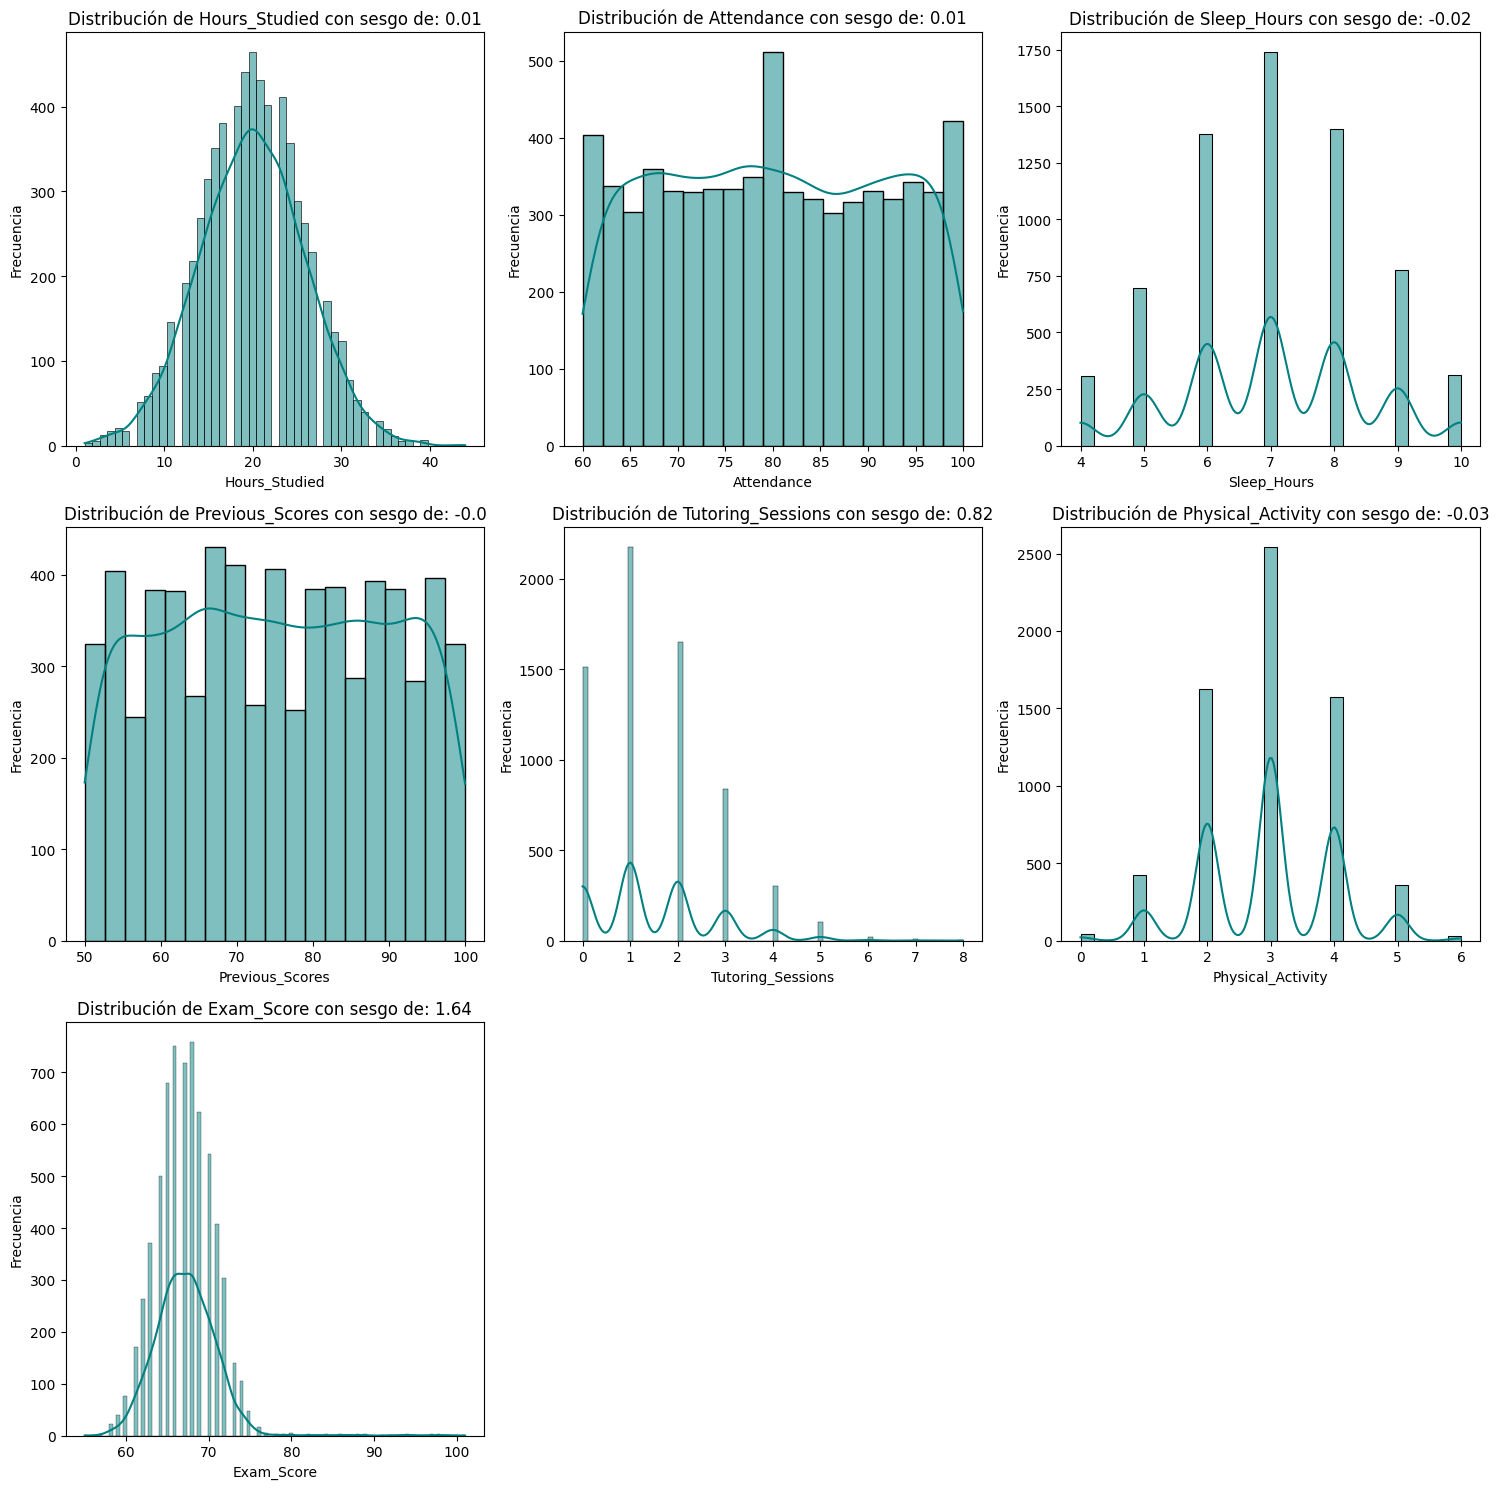

In [39]:
cols_numericas = df.select_dtypes(include="int64").columns

num_plots = len(cols_numericas)
cols = 3 
rows = math.ceil(num_plots / cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Aplano para iterar 

# Bucle para dibujar cada una
for i, col in enumerate(cols_numericas):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col} con sesgo de: {round(df[col].skew(), 2)}')
    axes[i].set_ylabel('Frecuencia')

#  Borrar marcos vacíos si sobran
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

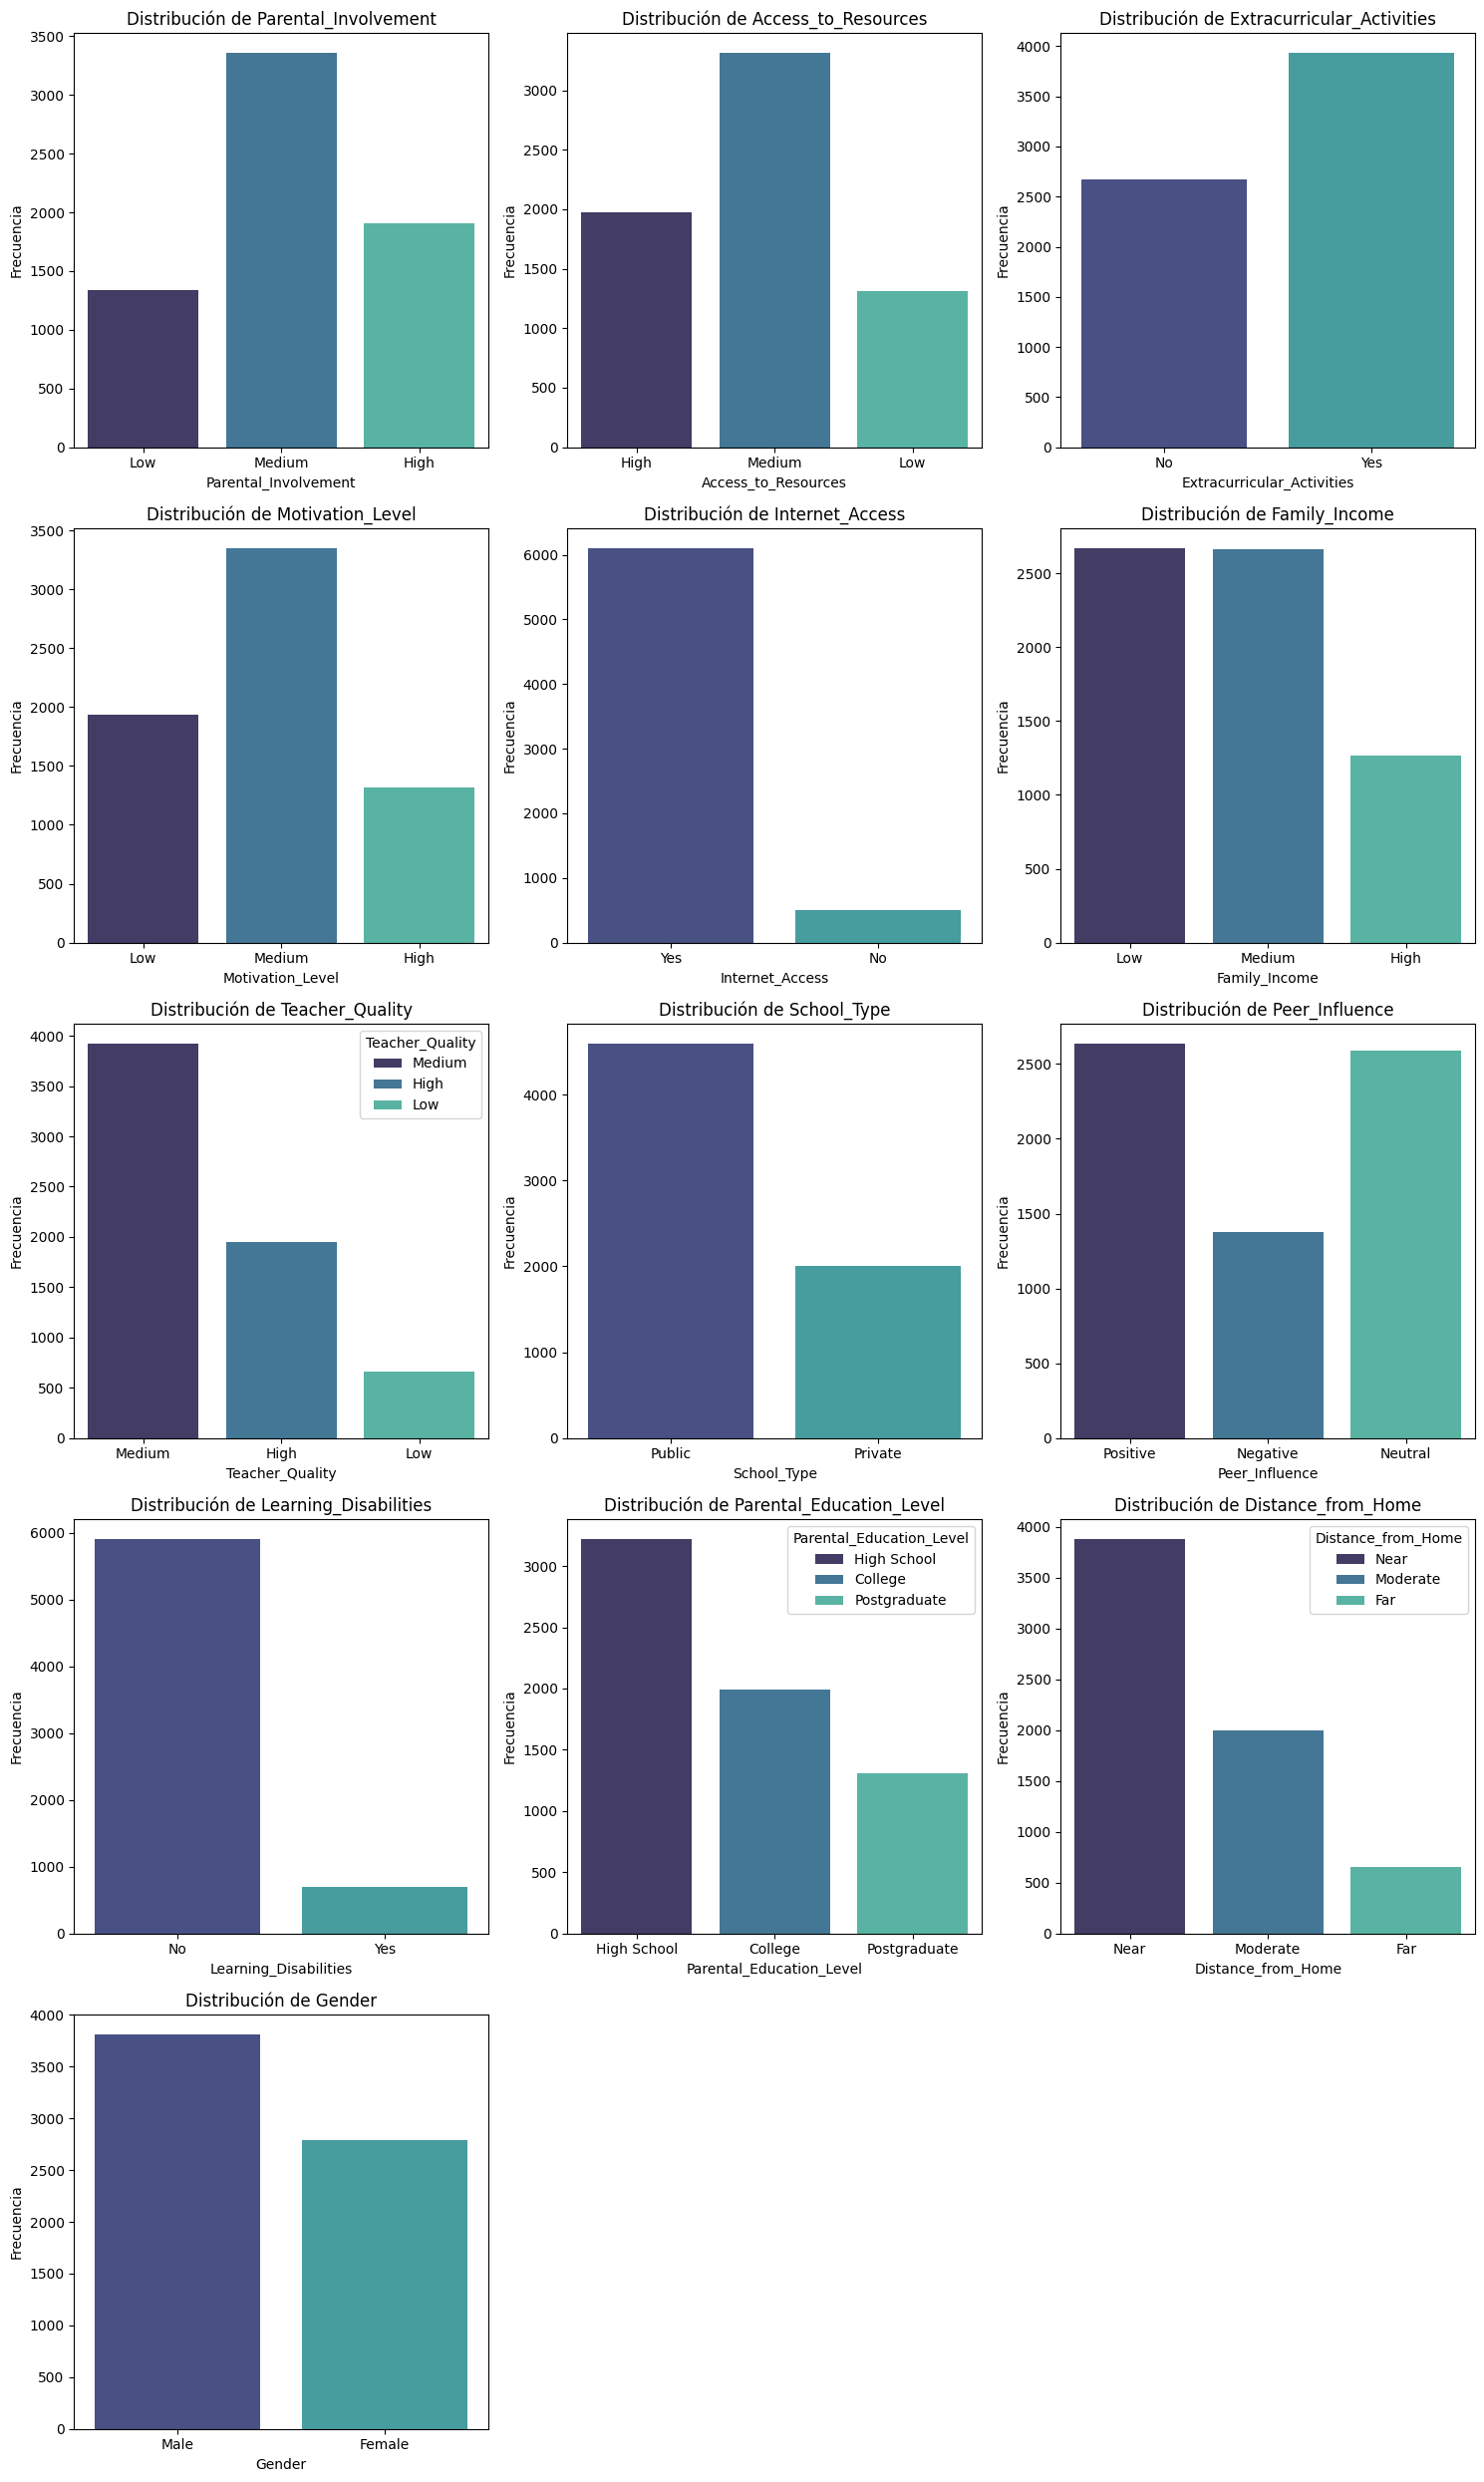

In [40]:
cols_categoricas = df.select_dtypes(include="object").columns

num_plots = len(cols_categoricas)
cols = 3 
rows = math.ceil(num_plots / cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Aplano para iterar 

# Bucle para dibujar cada una
for i, col in enumerate(cols_categoricas):
    sns.countplot(data=df, x=col, ax=axes[i],hue = col, palette='mako')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')

#  Borrar marcos vacíos si sobran
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [41]:
### Sesgo
print("---------Sesgo de variables numericas------------")
for i in cols_numericas:
    print(f"{i} : ",df[i].skew())

---------Sesgo de variables numericas------------
Hours_Studied :  0.013498908859762987
Attendance :  0.013665859547014896
Sleep_Hours :  -0.023805436886157025
Previous_Scores :  -0.00373653379826588
Tutoring_Sessions :  0.8155296028773414
Physical_Activity :  -0.031364712236934524
Exam_Score :  1.6448082853982677


- Exam Score esta altamente sesgada por lo tanto a la hora de modelar tengo que tenerlo en cuenta.
- Tutoring_sessions tambien presenata un sesgo moderado
- El resto de las variables presentan una distribucion aceptable

In [42]:
def anova_por_categorica(df, cat_cols, target):

    resultados = []

    for col in cat_cols:

        tmp = df[[col, target]].dropna()

        grupos = [
            tmp.loc[tmp[col] == categoria, target].values
            for categoria in tmp[col].unique()
        ]

        # ANOVA
        F, p = f_oneway(*grupos)

        # Eta squared
        total_mean = tmp[target].mean()

        ss_between = sum(
            len(g) * (g.mean() - total_mean) ** 2
            for g in grupos
        )

        ss_within = sum(
            ((g - g.mean()) ** 2).sum()
            for g in grupos
        )

        ss_total = ss_between + ss_within

        eta_sq = ss_between / ss_total if ss_total > 0 else 0

        resultados.append({
            "feature": col,
            "k_categorias": len(grupos),
            "anova_F": F,
            "p_value": p,
            "eta_squared": eta_sq,
            "n": len(tmp)
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("eta_squared", ascending=False)
        .reset_index(drop=True)
    )

In [43]:
anova_res = anova_por_categorica(df, cols_categoricas, "Exam_Score")
anova_res

,feature,k_categorias,anova_F,p_value,eta_squared,n
0,Access_to_Resources,3,98.004409,1.139299e-42,0.028825,6607
1,Parental_Involvement,3,84.487655,5.875479e-37,0.024948,6607
2,Parental_Education_Level,3,36.427196,1.852183e-16,0.011061,6517
3,Peer_Influence,3,34.052077,1.936891e-15,0.010207,6607
4,Family_Income,3,29.793861,1.314369e-13,0.008942,6607
5,Distance_from_Home,3,27.359262,1.470541e-12,0.008301,6540
6,Motivation_Level,3,25.716770,7.492319e-12,0.007728,6607
7,Learning_Disabilities,2,48.143389,4.338624e-12,0.007236,6607
8,Teacher_Quality,3,19.639367,3.135429e-09,0.005983,6529
9,Extracurricular_Activities,2,27.491709,1.626678e-07,0.004145,6607


Basandome en este test ANOVA veo q las ultimas 2 feaures(Gender y School_Type) me dieron un P-value bastante bajo y un eta_squared que tienen una varianza explicada muy poco signficativa, voy a proceder a dropearlas y a la hora de modelarel baseline voy a decidir si dropeo las 5 anteriores dependiendo del trade-off performance-ruido

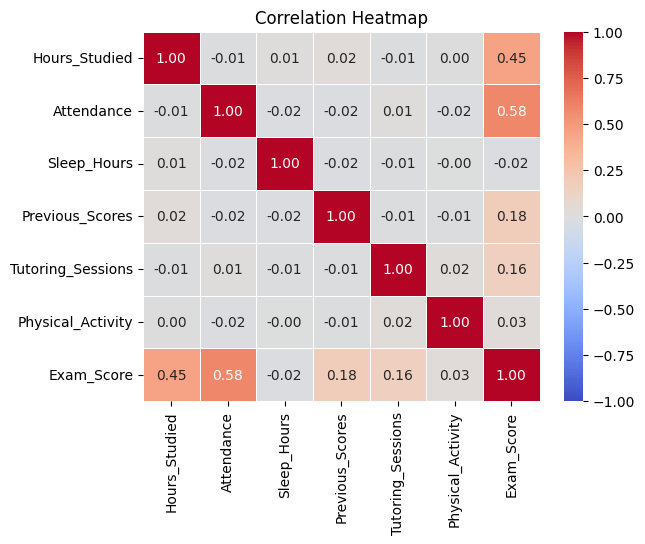

In [44]:
sns.heatmap(
    df[cols_numericas].corr(),
    annot=True,           
    cmap='coolwarm',      
    fmt=".2f",            
    linewidths=.5,        
    vmin=-1, vmax=1       
)

plt.title('Correlation Heatmap')
plt.show()

In [45]:
def outliers(data):

    Q1 = data.quantile(0.25)

    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1


    outliers = data[(data > Q3 + 1.5*IQR) | (data < Q1 - 1.5*IQR)]

    return outliers

In [46]:
print("------Outliers------")
for i in cols_numericas:
    print(f"{i} : ", len(outliers(df[i])))

------Outliers------
Hours_Studied :  43
Attendance :  0
Sleep_Hours :  0
Previous_Scores :  0
Tutoring_Sessions :  430
Physical_Activity :  0
Exam_Score :  104


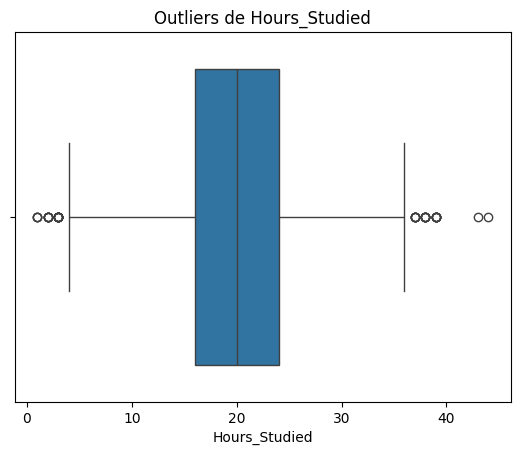

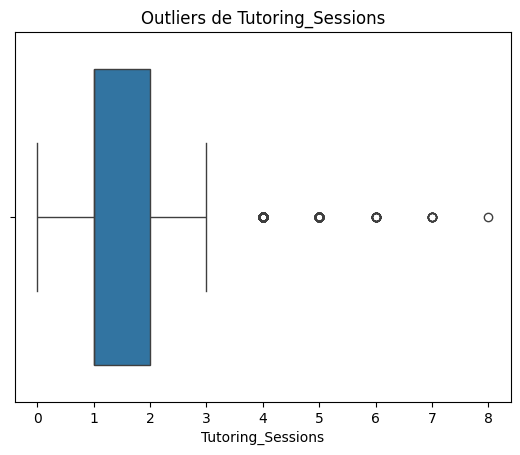

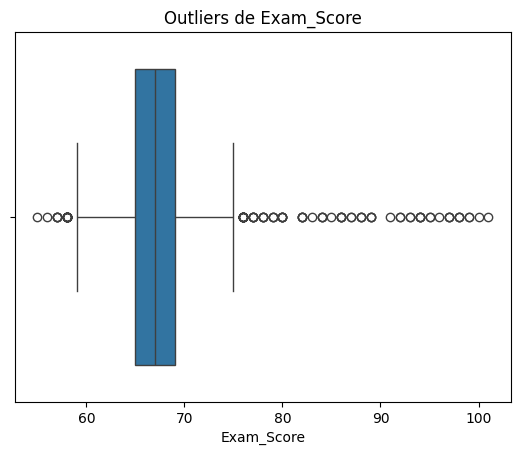

In [47]:
for i in cols_numericas:
    if len(outliers(df[i])) > 0:
        plt.figsize=(15,10)
        sns.boxplot(x = df[i])
        plt.title(f"Outliers de {i}")
        plt.show()

In [48]:
df["Tutoring_Sessions"].value_counts()

Tutoring_Sessions
1    2179
2    1649
0    1513
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

## MODELING

In [49]:
def identify_column_types(df):
    """
    Identifica automáticamente qué columnas son numéricas y categóricas
    
    Args:
        df: DataFrame
    
    Returns:
        dict con 'numerical' y 'categorical' columns
    """
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    return {
        'numerical': numerical_cols,
        'categorical': categorical_cols
    }


def create_preprocessor(X_train, numerical_strategy='standard', categorical_strategy='onehot'):
    """
    Crea un pipeline de preprocesamiento con ColumnTransformer
    
    Args:
        X_train: DataFrame de entrenamiento para identificar tipos de columnas
        numerical_strategy: 'standard', 'minmax', o 'none'
        categorical_strategy: 'onehot', 'label', o 'none'
    
    Returns:
        ColumnTransformer configurado
    """
    column_types = identify_column_types(X_train)
    numerical_cols = column_types['numerical']
    categorical_cols = column_types['categorical']
    
    
    transformers = []
    
    # Pipeline para columnas numéricas
    if numerical_cols and numerical_strategy != 'none':
        if numerical_strategy == 'standard':
            num_transformer = StandardScaler()
        elif numerical_strategy == 'minmax':
            num_transformer = MinMaxScaler()
        else:
            raise ValueError(f"Estrategia numérica desconocida: {numerical_strategy}")
        
        transformers.append(('num', num_transformer, numerical_cols))
    
    # Pipeline para columnas categóricas
    if categorical_cols and categorical_strategy != 'none':
        if categorical_strategy == 'onehot':
            cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        elif categorical_strategy == 'label':
            cat_transformer = LabelEncoder()
        else:
            raise ValueError(f"Estrategia categórica desconocida: {categorical_strategy}")
        
        transformers.append(('cat', cat_transformer, categorical_cols))
    
    # Crea ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'  # Mantener columnas no especificadas
    )
    
    return preprocessor


def preprocess_features(X_train, X_test, numerical_strategy='standard', 
                       categorical_strategy='onehot'):
    """
    Aplica preprocesamiento a los datos de train y test
    IMPORTANTE: Fit solo en train, transform en ambos
    
    Args:
        X_train: DataFrame de entrenamiento
        X_test: DataFrame de prueba
        numerical_strategy: Estrategia para columnas numéricas
        categorical_strategy: Estrategia para columnas categóricas
    
    Returns:
        X_train_processed, X_test_processed, preprocessor
    """
    # Crea preprocessor
    preprocessor = create_preprocessor(X_train, numerical_strategy, categorical_strategy)
    
    # FIT solo con datos de entrenamiento (CRÍTICO para evitar data leakage)
    print("Ajustando preprocessor con datos de entrenamiento...")
    preprocessor.fit(X_train)
    
    # TRANSFORM en ambos conjuntos
    print("Transformando datos de entrenamiento...")
    X_train_processed = preprocessor.transform(X_train)
    
    print("Transformando datos de prueba...")
    X_test_processed = preprocessor.transform(X_test)
    
    # Convertir a DataFrame si se desea mantener nombres de columnas
    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
        X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
        X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)
    
    
    return X_train_processed, X_test_processed

In [50]:
X = df.drop(columns="Exam_Score")
y = df["Exam_Score"]


X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
    )

X_train_processed, X_test_processed = preprocess_features(X_train, X_test, numerical_strategy='standard', categorical_strategy='onehot')

models = {
    'linear': LinearRegression(),
    'random_forest': RandomForestRegressor(),
    'xgboost': XGBRegressor(),
    'gradient_boosting': GradientBoostingRegressor()
}
models_results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    models_results[name] = {
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Comparar

df_results = pd.DataFrame(models_results).T
print(df_results.sort_values('R2', ascending=False))

Ajustando preprocessor con datos de entrenamiento...
Transformando datos de entrenamiento...
Transformando datos de prueba...
                         R2       MAE      RMSE
linear             0.769928  0.449950  1.803353
gradient_boosting  0.736669  0.784140  1.929302
random_forest      0.667959  1.088744  2.166432
xgboost            0.662061  0.979027  2.185588


-Bandome en las metricas de prueba de estos 4 modelos me quedo con los 2 que mejor rindieron, LineaRegression y gradient boosting.

In [51]:
## Aranco con los el hyperparameter tuning de los modelos lineales

ridge = Ridge(alpha=1.0)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

linear_poly = LinearRegression()
linear_poly.fit(X_train_poly, y_train)
print(f"Linear + Poly R²: {linear_poly.score(X_test_poly, y_test):.2f}")

param_grids = {
    'ridge': {
        'alpha': [12,14,15,16],
    }}

gs = GridSearchCV(
        estimator=ridge,
        param_grid=param_grids.get("ridge"),
        cv=5,
        scoring='r2', 
        n_jobs=-1,    
        verbose=1
    )
    
gs.fit(X_train_processed, y_train)
    

best_score = gs.best_score_
best_params = gs.best_params_
best_model = gs.best_estimator_

print("Mejor hipermarametro alpha: ",best_params)
print(f"El R2 promedio de los Folds es de {best_score:.2f}")

Linear + Poly R²: 0.74
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejor hipermarametro alpha:  {'alpha': 15}
El R2 promedio de los Folds es de 0.72


In [52]:
modeloRidge = Ridge(alpha=15)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

r2_ridge = r2_score(y_test,y_pred)
mae_ridge= mean_absolute_error(y_test,y_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_test,y_pred))


print("-----------Metricas Ridge-------------")
print(f"Test R²: {r2_ridge:.4f}")
print(f"Test MAE: {mae_ridge:.4f}")
print(f"Test RMSE: {rmse_ridge:.4f}")


-----------Metricas Ridge-------------
Test R²: 0.7355
Test MAE: 0.7868
Test RMSE: 1.9334


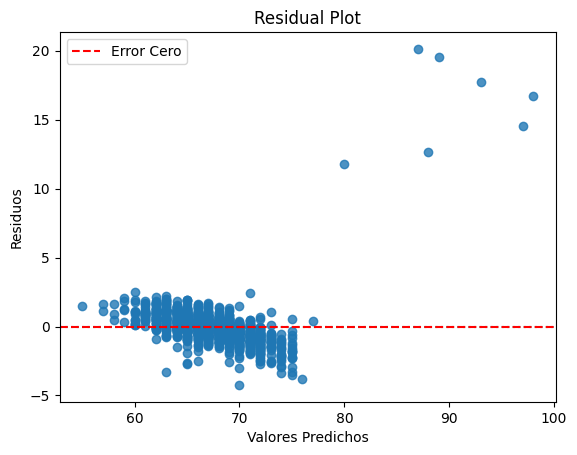

In [53]:
import seaborn as sns

residuals = y_test - y_pred

sns.residplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', label='Error Cero')

plt.title('Residual Plot')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.legend()
plt.show()


In [54]:
### Ahora gradient boosting

model = GradientBoostingRegressor(random_state=42)

param_grid_basic = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [10, 20]
}

random_search = GridSearchCV(
    estimator=model,
    n_jobs=-1,
    param_grid = param_grid_basic,
    cv = 5,
    scoring="r2",
)

random_search.fit(X_train_processed, y_train)

best_score = random_search.best_score_
best_params = random_search.best_params_
best_model = random_search.best_estimator_

print("Mejor hipermarametro alpha: ",best_params)
print(f"El R2 promedio de los Folds es de {best_score:.2f}")

Mejor hipermarametro alpha:  {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 20, 'n_estimators': 200}
El R2 promedio de los Folds es de 0.70


In [55]:
modeloGBoosting = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=30,
    n_estimators=200
)

modeloGBoosting.fit(X_train_processed, y_train)

y_pred = modeloGBoosting.predict(X_test_processed)

r2_GBoosting = r2_score(y_test,y_pred)
mae_GBoosting= mean_absolute_error(y_test,y_pred)
rmse_GBoosting= np.sqrt(mean_squared_error(y_test,y_pred))


print("----------------Metricas Gradient Boosting--------------")
print(f"Test R²: {r2_GBoosting:.4f}")
print(f"Test MAE: {mae_GBoosting:.4f}")
print(f"Test RMSE: {rmse_GBoosting:.4f}")

## Tomo esta metrica para comparar directamente con el test ya que en el gridSearch me habia dado un R2 mas bajo q el del test por lo q sospeche que habia algo de underfitting.
print(f"R2 train -->> {modeloGBoosting.score(X_train_processed,y_train)}")



----------------Metricas Gradient Boosting--------------
Test R²: 0.7521
Test MAE: 0.6569
Test RMSE: 1.8719
R2 train -->> 0.77502599057518


In [56]:
metricas = ["R²", "MAE", "RMSE"]

m_ridge= [r2_ridge, mae_ridge, rmse_ridge]

m_gboosting = [r2_GBoosting, mae_GBoosting,rmse_GBoosting]

df_metricas = pd.DataFrame({
    'Metrica': metricas,
    'Ridge': m_ridge,
    'GBoosting': m_gboosting
})
print("-------Comparativa desempeño-------\n")
print(df_metricas.head())

-------Comparativa desempeño-------

  Metrica     Ridge  GBoosting
0      R²  0.735548   0.752103
1     MAE  0.786831   0.656941
2    RMSE  1.933404   1.871909


Tomando esta tabla como referencia voy a usar el modelo de Grandient Boosting